# **Earnings Probability Model Analysis**

## Earnings Probability Notebook for all calculated stock features

### Covers Earnings metrics including EPS analysis, GAAP adjustments, and revision trends. Source functions:
- `probabilistic_ml_model.pymc_models.EarningsBeatModel.EarningsBeatBayesian` — hierarchical Beta-Binomial beat-probability model with DB-aligned `pm.Data` containers (`n_total`, `n_beats`, `sector_idx`, `earnings_features`).
- `public.vw_features_earnings` — source view for earnings features.
- `public.calculated_features_registry` (category = `Earnings`) — drives the `earnings_feature` coord labels.


In [1]:
import numpy as np
import pandas as pd
import xarray as xr

try:
    import arviz as az
except ImportError:
    import arviz_base as az
import arviz_plots as azp
import arviz_stats as azs
import matplotlib.pyplot as plt

from probabilistic_ml_model.pymc_models.EarningsBeatModel import EarningsBeatBayesian
from probabilistic_ml_model.pymc_models.PriceTargetModel import PriceTargetAchievement
from probabilistic_ml_model.pymc_models.KalmanFilterModel import KalmanFilterPriceTarget
from probabilistic_ml_model.pymc_models.DCF_PriceTargetModel import DCFPriceTarget
from probabilistic_ml_model.pymc_models.DividendSafetyModel import DividendSafetyBayesian
from probabilistic_ml_model.pymc_models.CreditRiskModel import CreditRiskBayesian
from probabilistic_ml_model.pymc_models.AccountingAnomalyModel import AccountingAnomalyBayesian
from probabilistic_ml_model.data_utils.data_utils import load_feature_categories_from_db
from probabilistic_ml_model.data_utils.inference_schema import (
    summarize_inference_data,
    EquityCoordinates,
    FeatureCoordinates,
)
from probabilistic_ml_model.statistical_functions.statistical_models import (
    bayesian_category_analysis,
    fit_distributions_by_category,
)


In [2]:
%%sql
select * from public.mv_all_stock_features masf
order by isin


,isin,ticker,name,description,region,country,trading_country,exchange,sector,industry,...,eps_gaap_vs_norm_ntm,eps_gaap_vs_norm_fy1e,forward_adjustment_trend,ebitda_est_ntm,ebitda_est_fy1e,ev_ebitda_est_fy1,ebitda_forward_growth,earnings_revision_divergence,forward_pe_vs_sector_proxy,feature_calculated_at
0,AEA001901015,AGTHIA,Agthia Group PJSC,Agthia Group PJSC operates in the food and bev...,Africa / Middle East,AE,AE,ADX,Consumer Staples,Food Products,...,0.01,0.01,0.01,173.32,173.32,7.4,0.521819,0.0144,-0.343915,2026-04-29 20:25:57.568917+02
1,AEA002301017,ARMX,Aramex PJSC,Aramex PJSC together with its subsidiaries inv...,Africa / Middle East,AE,AE,DFM,Industrials,Air Freight and Logistics,...,0.01,0.01,NaN,149.74,149.74,7.2,0.693317,NaN,NaN,2026-04-29 20:25:57.568917+02
2,AEA002401015,TAQA,Abu Dhabi National Energy Company PJSC,Abu Dhabi National Energy Company PJSC togethe...,Africa / Middle East,AE,AE,ADX,Utilities,Multi-Utilities,...,0.00,0.00,NaN,5494.27,5494.27,16.4,0.035477,NaN,0.017588,2026-04-29 20:25:57.568917+02
3,AEA003001012,AIRARABIA,Air Arabia PJSC,Air Arabia PJSC together with its subsidiaries...,Africa / Middle East,AE,AE,DFM,Industrials,Passenger Airlines,...,0.01,0.01,0.01,566.50,566.50,10.5,0.217311,-0.0205,0.485149,2026-04-29 20:25:57.568917+02
4,AEA004601018,ADPORTS,Abu Dhabi Ports Company PJSC,Abu Dhabi Ports Company PJSC operates in the p...,Africa / Middle East,AE,AE,ADX,Industrials,Transportation Infrastructure,...,0.01,0.01,NaN,1415.46,1415.46,9.2,0.146549,0.0974,-0.295238,2026-04-29 20:25:57.568917+02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6648,ZAE000320321,PMR,Premier Group Limited,Premier Group Limited operates as a consumer-p...,Africa / Middle East,ZA,ZA,JSE,Consumer Staples,Food Products,...,-0.03,-0.03,NaN,167.34,167.34,9.1,0.199570,0.0246,0.126866,2026-04-29 20:25:57.568917+02
6649,ZAE000322095,NPK,Nampak Limited,Nampak Limited engages in the manufacture and ...,Africa / Middle East,ZA,ZA,JSE,Materials,Containers and Packaging,...,0.00,0.00,NaN,100.61,100.61,4.9,-0.034823,0.0000,0.115385,2026-04-29 20:25:57.568917+02
6650,ZAE000332789,WBC,We Buy Cars Holdings Limited,We Buy Cars Holdings Limited engages in buying...,Africa / Middle East,ZA,ZA,JSE,Consumer Discretionary,Specialty Retail,...,0.00,0.00,NaN,109.88,109.60,9.8,0.326877,0.0000,NaN,2026-04-29 20:25:57.568917+02
6651,ZAE000339891,BOX,Boxer Retail Limited,Boxer Retail Limited operates a chain of super...,Africa / Middle East,ZA,ZA,JSE,Consumer Staples,Consumer Staples Distribution and Retail,...,0.00,0.00,NaN,244.31,230.91,10.4,0.324253,-0.0026,NaN,2026-04-29 20:25:57.568917+02


In [3]:
df.describe()


,reporting_interval,market_cap,enterprise_value,last_price,price_target,price_target_high,price_target_low,price_target_median,volume_shrs,shares_outstanding,...,pe_forward_discount,eps_gaap_vs_norm_ntm,eps_gaap_vs_norm_fy1e,forward_adjustment_trend,ebitda_est_ntm,ebitda_est_fy1e,ev_ebitda_est_fy1,ebitda_forward_growth,earnings_revision_divergence,forward_pe_vs_sector_proxy
count,6562.00000,6.653000e+03,6.642000e+03,6.653000e+03,6.653000e+03,6.653000e+03,6.653000e+03,6.653000e+03,6.616000e+03,6.653000e+03,...,4965.000000,5540.000000,5471.000000,3405.000000,6653.000000,6653.000000,6019.000000,6584.000000,4544.000000,5183.000000
mean,8.98217,1.667113e+04,1.906386e+04,5.784763e+03,6.266451e+03,8.051606e+03,4.298563e+03,6.255864e+03,8.560165e+06,1.660366e+09,...,-0.155719,-0.277110,-0.243707,-0.900969,1656.728312,1613.081691,14.729772,0.005671,0.737641,-0.078239
std,4.16247,1.237378e+05,1.246495e+05,5.927975e+04,6.793048e+04,8.687403e+04,5.027942e+04,6.784010e+04,3.113746e+07,1.043160e+10,...,0.956232,3.759341,1.430894,4.162803,9389.928704,8861.135829,21.318021,23.708552,50.994082,1.443795
min,3.00000,1.190000e+01,-1.631880e+03,3.000000e-03,1.030000e-02,1.200000e-02,8.600000e-03,1.030000e-02,0.000000e+00,2.300090e+05,...,-1.000000,-261.050000,-62.380000,-116.700000,-3267.520000,-3114.400000,0.300000,-1371.000000,-85.635200,-1.000000
25%,3.00000,1.057490e+03,1.295980e+03,1.226000e+01,1.572220e+01,1.850000e+01,1.241000e+01,1.550000e+01,1.377710e+05,6.451865e+07,...,-0.421846,-0.140000,-0.150000,-0.970000,85.770000,85.020000,6.500000,0.032365,-0.014025,-0.484048
50%,12.00000,3.252440e+03,3.816675e+03,3.810000e+01,4.649170e+01,5.500000e+01,3.800000e+01,4.600000e+01,6.256210e+05,2.054774e+08,...,-0.217391,-0.010000,-0.010000,-0.050000,331.870000,324.770000,9.600000,0.193805,0.000000,-0.224215
75%,12.00000,8.752380e+03,1.085166e+04,1.382310e+02,1.606875e+02,1.923848e+02,1.290000e+02,1.600000e+02,3.679220e+06,7.686918e+08,...,-0.066225,0.000000,0.000000,0.030000,1037.850000,1024.410000,15.300000,0.452203,0.021900,0.038963
max,12.00000,5.051892e+06,5.000748e+06,1.604000e+06,2.200579e+06,2.613811e+06,1.900000e+06,2.200000e+06,7.068063e+08,5.742199e+11,...,27.449612,35.490000,35.230000,42.500000,297745.680000,267839.660000,480.500000,1205.000000,3436.115900,60.684211


In [4]:
%%sql
select *from public.feature_catalogue fc where source_function notnull
order by category

,category,feature_alias,source_function,calculation_type,data_type
0,Accounting Quality,tax_rate_qoq_change,calc_tax_rate_features,difference,NUMERIC
1,Accounting Quality,tax_rate_yoy_change,calc_tax_rate_features,difference,NUMERIC
2,Accounting Quality,asset_sale_trend,calc_asset_sale_features,difference,NUMERIC
3,Accounting Quality,asset_sale_frequency,calc_asset_sale_features,score,INTEGER
4,Accounting Quality,recent_acquisition_flag,calc_goodwill_temporal_features,flag,INTEGER
...,...,...,...,...,...
397,Valuation Timeseries,p_e_momentum_yoy,calc_valuation_timeseries_features,growth,NUMERIC
398,Valuation Timeseries,ev_ebitda_momentum,calc_valuation_timeseries_features,growth,NUMERIC
399,Valuation Timeseries,ev_sales_trend_1y,calc_valuation_timeseries_features,growth,NUMERIC
400,Valuation Timeseries,ev_ebitda_qoq_trend,calc_extended_valuation_timeseries,growth,NUMERIC


### Feature catalogue → master `FEATURE_CATEGORIES` dictionary

The SQL cell above binds `feature_catalogue` to a notebook-local DataFrame.
We turn it into a `{category: [feature_alias, ...]}` dictionary that mirrors
the pattern used in `pml_model_analysis.ipynb` and replaces the previous
`load_feature_categories_from_db()` call. This keeps the notebook
self-contained while staying DB-aligned via `public.calculated_features_registry`.


In [5]:
# Master dict: {category: [feature_alias, ...]} - DB-aligned via feature_catalogue.
FEATURE_CATEGORIES: dict[str, list[str]] = (
    feature_catalogue
    .dropna(subset=["source_function"])
    .groupby("category")["feature_alias"]
    .apply(lambda s: list(dict.fromkeys(s)))   # de-dup, preserve order
    .to_dict()
)
print(f"Loaded {len(FEATURE_CATEGORIES)} categories, "
      f"{sum(len(v) for v in FEATURE_CATEGORIES.values())} feature aliases.")


# Helper: resolve a list of categories to columns actually present in df.
def resolve_features(*categories: str, frame: pd.DataFrame = None) -> list[str]:
    frame = df if frame is None else frame
    seen, out = set(), []
    for cat in categories:
        for alias in FEATURE_CATEGORIES.get(cat, []):
            if alias in frame.columns and alias not in seen:
                seen.add(alias)
                out.append(alias)
    return out


# Backwards compatibility: existing cells reference `earnings_categories`.
earnings_categories = FEATURE_CATEGORIES


Loaded 27 categories, 401 feature aliases.


# Statistical Analysis: Bayesian Category Analysis

In [6]:
# Bayesian analysis on ALL feature categories (excluding "direct" calculation_type features)

for category, features in FEATURE_CATEGORIES.items():
    # Filter out "direct" features and keep only those present in df
    available = [f for f in features if f in df.columns and f not in feature_catalogue]
    if available:
        print(f"\n{'=' * 60}")
        print(f"  Bayesian Analysis: {category} ({len(available)} features)")
        print(f"{'=' * 60}")
        result = bayesian_category_analysis(df, category, available)
        if isinstance(result, dict):
            for feat, stats in result.items():
                if isinstance(stats, dict):
                    print(f"\n  {feat}:")
                    for k, v in stats.items():
                        if isinstance(v, (int, float)):
                            print(f"    {k}: {v:.4f}")
    else:
        skipped_reason = "all features are 'direct' or not in df"
        print(f"\n  [Skipped] {category}: {skipped_reason}")


  Bayesian Analysis: Accounting Quality (20 features)

  tax_rate_qoq_change:
    n_obs: 6653.0000
    sample_mean: -0.0297
    sample_std: 2.3813
    posterior_mean: -0.0297
    posterior_std: 0.0292
    ci_95_low: -0.0869
    ci_95_high: 0.0275
    prob_positive: 0.1543

  tax_rate_yoy_change:
    n_obs: 6653.0000
    sample_mean: -0.0776
    sample_std: 4.7632
    posterior_mean: -0.0776
    posterior_std: 0.0584
    ci_95_low: -0.1920
    ci_95_high: 0.0369
    prob_positive: 0.0920

  asset_sale_trend:
    n_obs: 6653.0000
    sample_mean: -3.2583
    sample_std: 187.5321
    posterior_mean: -3.0947
    posterior_std: 2.2407
    ci_95_low: -7.4864
    ci_95_high: 1.2971
    prob_positive: 0.0836

  asset_sale_frequency:
    n_obs: 6653.0000
    sample_mean: 4.1517
    sample_std: 3.8584
    posterior_mean: 4.1516
    posterior_std: 0.0473
    ci_95_low: 4.0589
    ci_95_high: 4.2443
    prob_positive: 1.0000

  recent_acquisition_flag:
    n_obs: 6653.0000
    sample_mean: 0.0185

In [7]:
# Bayesian analysis on ALL feature categories (excluding "direct" calculation_type features)

for category, features in FEATURE_CATEGORIES.items():
    # Filter out "direct" features and keep only those present in df
    available = [f for f in features if f in df.columns and f not in feature_catalogue]
    if available:
        print(f"\n{'=' * 60}")
        print(f"  Distribution Fitting: {category} ({len(available)} features)")
        print(f"{'=' * 60}")
        result = fit_distributions_by_category(df, category, available, n_simulations=500)
        if isinstance(result, dict):
            for feat, info in result.items():
                if isinstance(info, dict) and "best_distribution" in info:
                    print(
                        f"  {feat}: best_distribution={info['best_distribution']}, "
                        f"aic={info.get('aic', 'N/A'):.4f}, "
                        f"params={info.get('params', 'N/A')}, "
                        f"simulated_mean={info.get('simulated_mean', 'N/A'):.4f}, "
                        f"simulated_std={info.get('simulated_std', 'N/A'):.4f}, "
                        f"cvar_5_pct={info.get('cvar_5_pct', 'N/A'):.4f}"
                    )
    else:
        skipped_reason = "all features are 'direct' or not in df"
        print(f"\n  [Skipped] {category}: {skipped_reason}")


  Distribution Fitting: Accounting Quality (20 features)
  tax_rate_qoq_change: best_distribution=student_t, aic=-14938.8735, params=(np.float64(0.4557528169258555), np.float64(-0.00011263020700394114), np.float64(0.0065326953242448565)), simulated_mean=-10.2445, simulated_std=228.8008, cvar_5_pct=-231.7483
  tax_rate_yoy_change: best_distribution=student_t, aic=-44605.2206, params=(np.float64(0.06985978580117046), np.float64(-2.9199729293065456e-12), np.float64(2.3663686248852163e-11)), simulated_mean=-267704277814684105857564672.0000, simulated_std=6020917787858643745522057216.0000, cvar_5_pct=-5390470811910705012252082176.0000
  asset_sale_trend: best_distribution=skew_normal, aic=46705.3315, params=(np.float64(-0.9058851204046592), np.float64(5.198970799314745), np.float64(10.315446797520659)), simulated_mean=-0.1560, simulated_std=8.7627, cvar_5_pct=-18.7120
  asset_sale_frequency: best_distribution=skew_normal, aic=32746.1123, params=(np.float64(2932465.818001656), np.float64(-9

### Per-model `feature_data` containers

Each container maps a PyMC model to its **target** (LHS observed variable),
its **observed/design** inputs (RHS `pm.Data` containers), and the
**catalogue-aligned auxiliary feature matrix**. This is the canonical
structure consumed in steps `X.1`-`X.2` of every model section below.


In [8]:
# Common id column
id_col = "isin" if "isin" in df.columns else "ticker"

MODEL_FEATURE_CONTAINERS: dict[str, dict] = {

    # --- Section 1-5: EarningsBeatBayesian -----------------------------------
    "EarningsBeat": {
        "target":   "n_beats",                                # Binomial successes
        "observed": {"eps_positive_years", "eps_total_reports", "sector", "eps_norm_est_num_fy1e",
                     "eps_surprise_pct",
                     "eps_quarterly_trend",
                     "eps_qoq_growth",
                     "eps_basic_fy",
                     "eps_trajectory_score",
                     "eps_cagr_5y",
                     "eps_growth_accel",
                     "eps_adj_ltm",
                     "eps_cagr_3y",
                     "eps_basic_fq",
                     "eps_adjustment_ratio",
                     "eps_positive_streak",
                     "eps_stability",
                     "eps_vs_5y_avg",
                     "gaap_adj_eps_gap_pct",
                     "eps_yoy_growth",
                     "eps_norm_est_fy1e",
                     "eps_basic_ltm",
                     "eps_improvement_count",
                     "eps_yoy_quarterly",
                     "eps_cont_qoq_growth",
                     "eps_cont_yoy_growth",
                     "eps_cont_cagr_3y",
                     "eps_cont_vs_total_eps",
                     "eps_cont_positive_streak",
                     "eps_cont_trajectory_score",
                     "forward_eps_gaap_adj_spread",
                     "composite_eps_trajectory_score",
                     "eps_revision_momentum", },
        "categories": ["Earnings Quality", "EPS Trajectory"],
        "features": resolve_features("Earnings Quality", "EPS Trajectory"),
    },

    # --- Section 6: PriceTargetAchievement -----------------------------------
    "PriceTarget": {
        "target":   "upside_potencial",                       # upside_obs
        "observed": ["upside_potential", "analyst_conviction","pt_vs_price_momentum"],
        "categories": ["Price Target Dynamics", "Analyst Sentiment"],
        "features": resolve_features("Price Target Dynamics", "Analyst Sentiment"),
    },

    # --- Section 7: KalmanFilterPriceTarget ----------------------------------
    "Kalman": {
        "target": "expected_upside",                           # GRW observation
        "observed": ["price_target_low",
                     "price_momentum_3y",
                     "price_momentum_3m",
                     "price_target_revision_3m",
                     "price_target_count",
                     "price_momentum_1m",
                     "price_momentum_1y",
                     "price_vs_ema_250d",
                     "price_vs_ema_20d",
                     "price_target_revision_1m",
                     "price_target_spread_pct",
                     "price_target_median",
                     "pt_vs_price_momentum",
                     "price_momentum_5d",
                     "price_target_high",
                     "price_vs_ema_100d",
                     "price_target",
                     "price_momentum_5y",
                     "price_momentum_6m",
                     "last_price",],
        "categories": ["Price Target Dynamics", "Technical Analysis"],
        "features": resolve_features("Price Target Dynamics", "Technical Analysis"),
    },

    # --- Section 8: DCFPriceTarget -------------------------------------------
    "DCF": {
        "target":   "price_target",                             # price_obs
        "observed": ["fcf_fy", "last_price"],
        "categories": ["Cash Flow", "Valuation Ratios"],
        "features": resolve_features("Cash Flow", "Valuation Ratios"),
    },

    # --- Section 9: DividendSafetyBayesian -----------------------------------
    "DividendSafety": {
        "target":   "fcf_dividend_coverage",                  # fcf_coverage_obs
        "observed": ["dividend_payout_ratio", "fcf_dividend_coverage"],
        "categories": ["Dividends", "Cash Flow"],
        "features": resolve_features("Dividends", "Cash Flow"),
    },

    # --- Section 10: CreditRiskBayesian --------------------------------------
    "CreditRisk": {
        "target":   "distress_target",                        # distress_obs
        "observed": ["altman_z_score", "debt_to_equity", "sector"],
        "categories": ["Credit Risk", "Quality & Risk", "Leverage & Liquidity"],
        "features": resolve_features("Credit Risk", "Quality & Risk",
                                     "Leverage & Liquidity"),
    },

    # --- Section 11: AccountingAnomalyBayesian -------------------------------
    "AccountingAnomaly": {
        "target":   "feature_values",                         # feature_obs (matrix)
        "observed": ["feature_values"],
        "categories": ["Accounting Quality", "Quality & Risk", "Unusual Items"],
        "features": resolve_features("Accounting Quality", "Quality & Risk",
                                     "Unusual Items"),
    },
}

# Quick coverage report
for _name, _spec in MODEL_FEATURE_CONTAINERS.items():
    print(f"{_name:18s}  target={_spec['target']:25s}  "
          f"#features={len(_spec['features'])}")


EarningsBeat        target=n_beats                    #features=35
PriceTarget         target=upside_potencial           #features=31
Kalman              target=expected_upside            #features=25
DCF                 target=price_target               #features=25
DividendSafety      target=fcf_dividend_coverage      #features=18
CreditRisk          target=distress_target            #features=35
AccountingAnomaly   target=feature_values             #features=35


### `attach_features` helper for `idata.constant_data`

Models that don't natively accept the auxiliary matrix
(`PriceTargetAchievement`, `DividendSafetyBayesian`, `CreditRiskBayesian`,
`DCFPriceTarget`) can still persist the catalogue-aligned feature matrix
into `idata.constant_data` post-fit, so `pm.set_data({...})` swaps remain
valid for out-of-sample prediction.


In [9]:
def attach_features(idata, features_df: pd.DataFrame, dim_name: str):
    """Append an (isin, feature) matrix to idata.constant_data."""
    feat_cols = [c for c in features_df.columns if c != "isin"]
    arr = features_df.set_index("isin")[feat_cols].to_numpy("float64")
    ds = xr.Dataset(
        {dim_name: (("isin", "feature"), arr)},
        coords={"isin": features_df["isin"].to_numpy(),
                "feature": feat_cols},
    )
    if "constant_data" in idata.groups():
        idata.constant_data = idata.constant_data.merge(ds)
    else:
        idata.add_groups({"constant_data": ds})
    return idata


## 1. Prepare inputs for `EarningsBeatBayesian`

We map columns from `public.mv_expected_returns` onto the model's `pm.Data` containers:

| Container           | Source column(s)                                                 |
|---------------------|------------------------------------------------------------------|
| `n_beats` (isin,)   | `eps_positive_years` (proxy for beats count)                     |
| `n_total` (isin,)   | `eps_total_reports` if available, else fixed 10-year window      |
| `isin`  coord       | `isin` (role=`id` in `vw_identifier_columns`)                    |
| `sector` coord      | `sector` (role=`categorical`) — enables hierarchical structure   |
| `earnings_features` | full earnings-feature matrix keyed by `calculated_features_registry` |


In [10]:
# Canonical ID column
id_col = "isin" if "isin" in df.columns else "ticker"

# Beats / totals
beats_col = "eps_positive_years"  # integer proxy for earnings beats
totals_col = "eps_total_reports" if "eps_total_reports" in df.columns else None
default_window = 10  # fallback lookback window

valid_mask = df[beats_col].notna() & df[id_col].notna()
eb_df = df.loc[valid_mask].drop_duplicates(subset=id_col).reset_index(drop=True)

if totals_col is not None:
    n_total = eb_df[totals_col].fillna(default_window).astype(int).clip(lower=1).to_numpy()
else:
    n_total = np.full(len(eb_df), default_window, dtype="int32")

n_beats = np.clip(eb_df[beats_col].astype(int).to_numpy(), 0, n_total)

isins = eb_df[id_col].astype(str).to_numpy()
sectors = eb_df["sector"].astype(str).to_numpy() if "sector" in eb_df.columns else None

print(f"Prepared inputs: {len(eb_df)} stocks")
print(f"  n_beats:  mean={n_beats.mean():.2f}  min={n_beats.min()}  max={n_beats.max()}")
print(f"  n_total:  mean={n_total.mean():.2f}  min={n_total.min()}  max={n_total.max()}")
if sectors is not None:
    print(f"  sectors:  {len(np.unique(sectors))} unique")


Prepared inputs: 6653 stocks
  n_beats:  mean=3.85  min=0  max=5
  n_total:  mean=10.00  min=10  max=10
  sectors:  9 unique


### 1.1 Build the auxiliary `earnings_features` matrix

The matrix is aligned to the `earnings_feature` dim whose labels are resolved from
`public.calculated_features_registry` (category = `Earnings Quality`).


In [11]:
spec = MODEL_FEATURE_CONTAINERS["EarningsBeat"]
earnings_feature_aliases = list(spec["features"])
print(f"[EarningsBeat] catalogue exposes {len(earnings_feature_aliases)} aliases "
      f"for categories {spec['categories']}.")

available_features = [c for c in earnings_feature_aliases if c in eb_df.columns]
print(f"  {len(available_features)} of them are present in vw_features_earnings.")

# The model's internal `_align_earnings_features` handles missing columns, so we
# can pass the full frame keyed by `isin` (de-duplicated up-front).
earnings_features_df = (
    eb_df[[id_col] + available_features]
    .rename(columns={id_col: "isin"})
    .drop_duplicates(subset="isin")
)


[EarningsBeat] catalogue exposes 35 aliases for categories ['Earnings Quality', 'EPS Trajectory'].
  35 of them are present in vw_features_earnings.


## 2. Fit the hierarchical Beta-Binomial model

The model stores observed/design data as `pm.Data` containers so they appear in
`idata.constant_data` and can be swapped via `pm.set_data({...})` for
out-of-sample prediction.


In [12]:
earnings_bayesian = EarningsBeatBayesian()

print(f"Sampling EarningsBeatBayesian over {len(eb_df)} stocks "
      f"({'hierarchical by sector' if sectors is not None else 'pooled'})...")

earnings_idata, earnings_bayesian_model = earnings_bayesian.fit(
    n_beats=n_beats,
    n_total=n_total,
    isins=isins,
    sectors=sectors,
    earnings_features_df=earnings_features_df,
    samples=1000,
    tune=1000,
    chains=4,
    target_accept=0.8,
    random_seed=42,
    parameterization="marginalized",  # collapses 500 per-stock Beta latents
    nuts_sampler="nutpie",  # Rust NUTS — ~5–10x faster than pure-Python pymc sampler
    idata_kwargs={"log_likelihood": False},
)

earnings_idata

Sampling EarningsBeatBayesian over 6653 stocks (hierarchical by sector)...


C:\Users\markm\AppData\Local\Programs\Python\Python314\Lib\site-packages\pymc\sampling\mcmc.py:361: UserWarning: `idata_kwargs` are currently ignored by the nutpie sampler
  warnings.warn(


Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.33,7
,2000,2,0.28,23
,2000,0,0.32,63
,2000,1,0.34,31


Inference data with groups:
	> posterior
	> sample_stats
	> observed_data
	> constant_data

Warmup iterations saved (warmup_*).

## 3. Inspect the `constant_data` group

`pm.Data` containers are automatically persisted into `idata.constant_data`,
carrying the DB-aligned coords (`isin`, `sector`, `earnings_feature`).


In [13]:
if hasattr(earnings_idata, "constant_data"):
    print("constant_data variables:", list(earnings_idata.constant_data.data_vars))
    print("constant_data coords:   ", list(earnings_idata.constant_data.coords))
    print(earnings_idata.constant_data)


constant_data variables: ['n_total', 'n_beats', 'earnings_features', 'sector_idx']
constant_data coords:    ['isin', 'earnings_feature']
<xarray.Dataset> Size: 2MB
Dimensions:            (isin: 6653, earnings_feature: 21)
Coordinates:
  * isin               (isin) <U12 319kB 'AEA001901015' ... 'ZAE000351946'
  * earnings_feature   (earnings_feature) <U27 2kB 'eps_surprise_pct' ... 'ep...
Data variables:
    n_total            (isin) int32 27kB 10 10 10 10 10 10 ... 10 10 10 10 10 10
    n_beats            (isin) int32 27kB 5 4 5 5 5 5 5 5 5 ... 4 4 5 5 4 2 5 4 5
    earnings_features  (isin, earnings_feature) float64 1MB -62.5 -7.086 ... 0.0
    sector_idx         (isin) int32 27kB 2 5 8 5 5 1 3 5 3 ... 1 3 7 5 2 7 1 2 1
Attributes:
    created_at:                 2026-04-29T18:35:22.517529+00:00
    creation_library:           ArviZ
    creation_library_version:   1.0.0
    creation_library_language:  Python
    inference_library:          pymc
    inference_library_version:  5.28.4


## 4. Posterior diagnostics


In [14]:
summary = azs.summary(
    earnings_idata,
    var_names=(["sector_rate", "kappa", "mu_logit", "sigma_sector"] if sectors is not None else ["mu_logit"]),
    round_to=3,
)
summary.head(20)


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
sector_rate[Communication Services],0.371,0.008,0.357,0.384,5685.494,3107.853,1.000,0.000,0.000
sector_rate[Consumer Discretionary],0.401,0.005,0.393,0.409,5302.958,3355.544,1.001,0.000,0.000
sector_rate[Consumer Staples],0.434,0.007,0.422,0.446,5662.079,3131.925,1.000,0.000,0.000
sector_rate[Energy],0.393,0.009,0.378,0.406,5046.663,2937.614,1.001,0.000,0.000
sector_rate[Health Care],0.272,0.005,0.263,0.281,4551.744,3619.895,1.000,0.000,0.000
sector_rate[Industrials],0.418,0.004,0.411,0.425,4865.976,3315.115,1.001,0.000,0.000
sector_rate[Information Technology],0.375,0.005,0.367,0.383,5893.862,3425.897,1.000,0.000,0.000
sector_rate[Materials],0.381,0.006,0.371,0.391,6473.233,3346.363,1.001,0.000,0.000
sector_rate[Utilities],0.435,0.010,0.419,0.450,5554.580,3295.980,1.001,0.000,0.000
kappa,58.503,7.486,47.910,71.336,3164.385,2462.249,1.001,0.138,0.116


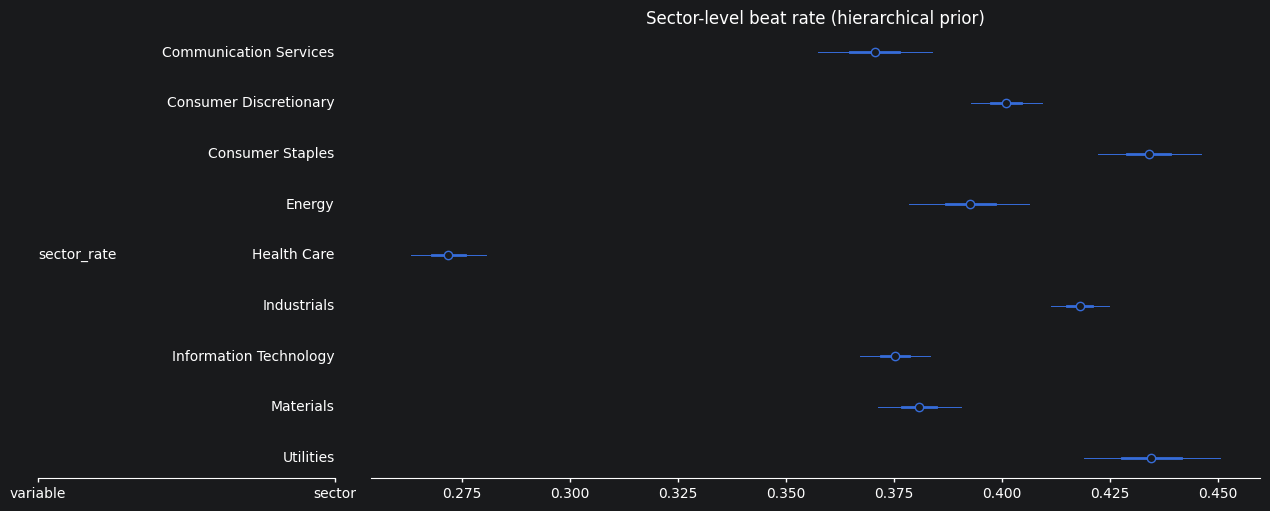

In [15]:
if sectors is not None:
    azp.plot_forest(earnings_idata, var_names=["sector_rate"], combined=True)
    plt.title("Sector-level beat rate (hierarchical prior)")
    plt.tight_layout()
    plt.show()


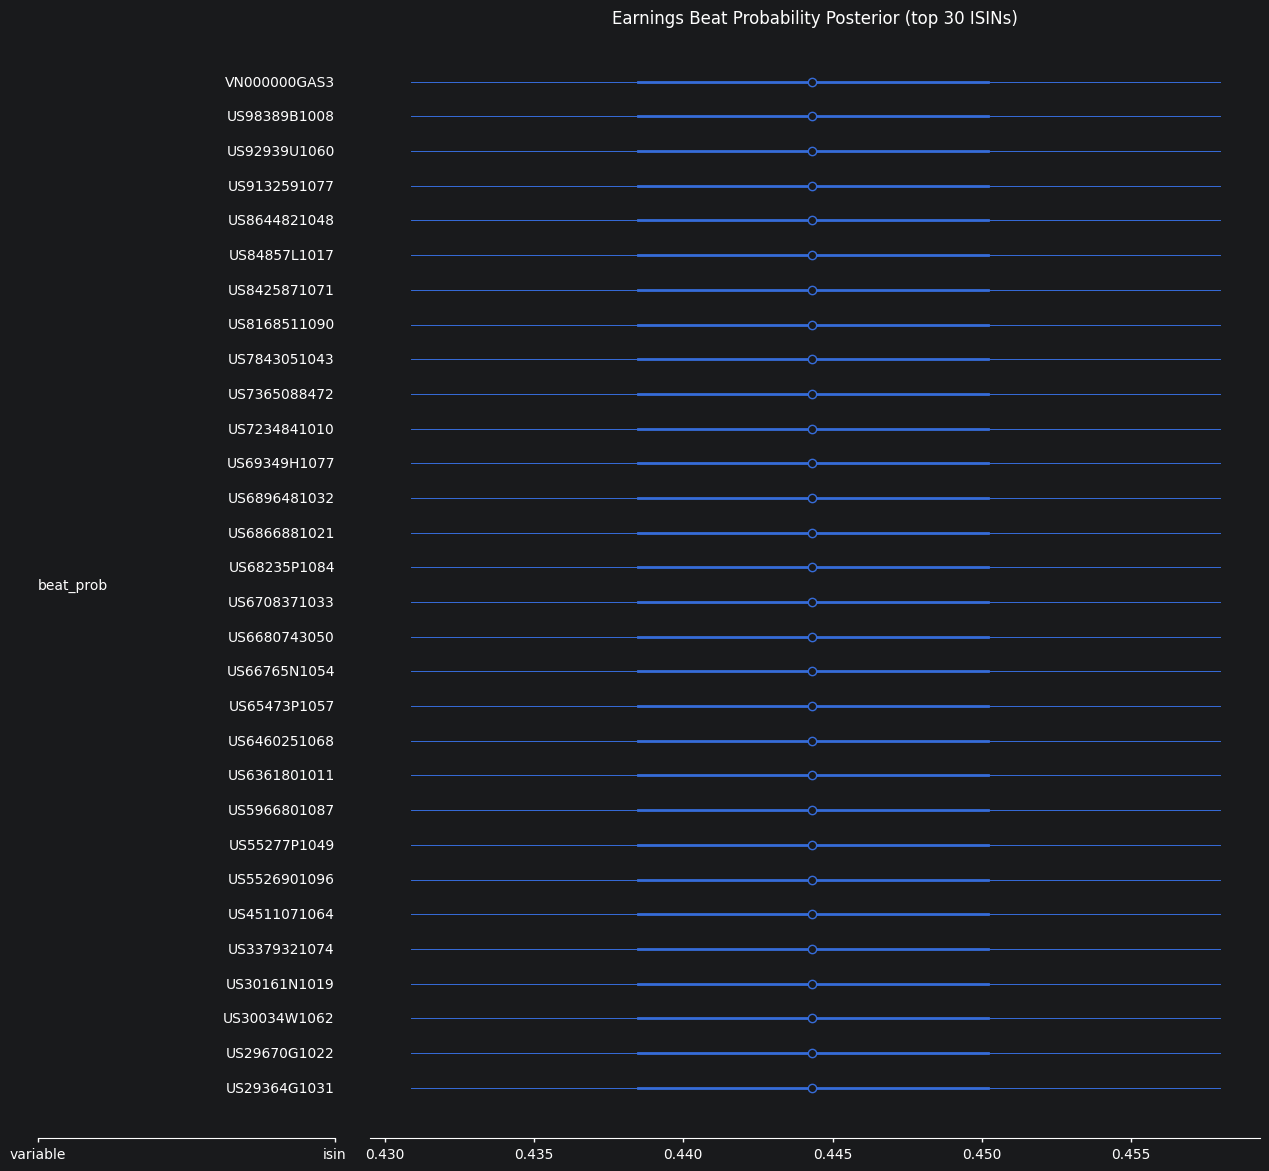

In [16]:
import xarray as xr

post = earnings_idata.posterior
if "beat_prob" in post.data_vars:
    beat_prob = post["beat_prob"]
else:
    kappa = post["kappa"]
    if "sector_rate" in post.data_vars and sectors is not None:
        # Map each ISIN's sector label to the integer index used by the model.
        sector_levels = post.coords["sector"].values            # 1D array of unique sectors
        sector_to_idx = {s: i for i, s in enumerate(sector_levels)}

        # eb_df["sector"] must align with the ISINs you're indexing into post for.
        isin_sectors = eb_df["sector"].to_numpy()
        sector_idx = np.array(
            [sector_to_idx[s] for s in isin_sectors],
            dtype=np.int64,
        )

        rate_per_isin = post["sector_rate"].isel(
            sector=xr.DataArray(sector_idx, dims="isin")
        )
    else:
        rate_per_isin = 1.0 / (1.0 + np.exp(-post["mu_logit"]))
    alpha_i = rate_per_isin * kappa
    beta_i = (1.0 - rate_per_isin) * kappa
    n_b = xr.DataArray(n_beats, dims="isin")
    n_t = xr.DataArray(n_total, dims="isin")
    beat_prob = (alpha_i + n_b) / (alpha_i + beta_i + n_t)
    beat_prob = beat_prob.assign_coords(isin=isins)
    earnings_idata.posterior = earnings_idata.posterior.assign(beat_prob=beat_prob)

top_n = min(30, len(isins))
beat_mean = beat_prob.mean(("chain", "draw"))
# Use ["isin"] (not .isin) — `.isin` collides with xarray's DataArray.isin() method.
top_isins = beat_mean.sortby(beat_mean, ascending=False)["isin"].values[:top_n]
azp.plot_forest(
    earnings_idata,
    var_names=["beat_prob"],
    coords={"isin": top_isins},
    combined=True,
)
plt.title(f"Earnings Beat Probability Posterior (top {top_n} ISINs)")
plt.tight_layout()
plt.show()


## 5. Out-of-sample prediction via `pm.set_data` (illustration)

The `n_total` and `earnings_features` containers are mutable, so new cohorts can be
scored without rebuilding the model graph:

```python
with earnings_bayesian_model:  # the model context returned by fit
    pm.set_data({
        "n_total": new_n_total,
        "earnings_features": new_features_matrix,
    })
    ppc = pm.sample_posterior_predictive(earnings_idata)
```

## 6. Price Target Achievement Model — `PriceTargetAchievement`

Source: `probabilistic_ml_model.pymc_models.PriceTargetModel.PriceTargetAchievement`.
Maps to `_resolve_price_target_inputs` in `inference_schema.py`.

### 6.1 Prepare inputs for `PriceTargetAchievement`

| Container               | Source column            | Dim    |
|-------------------------|--------------------------|--------|
| `upside_potential`      | `upside_potential`       | `isin` |
| `analyst_conviction`    | `analyst_conviction`     | `isin` |
| `isin` coord            | `isin` (role=`id`)       | —      |


In [17]:
pt_mask = (
    df["upside_potential"].notna()
    & df["analyst_conviction"].notna()
    & df[id_col].notna()
)
pt_df = df.loc[pt_mask].drop_duplicates(subset=id_col).reset_index(drop=True)

pt_inputs = dict(
    upside_potential=pt_df["upside_potential"].astype("float64").to_numpy(),
    analyst_conviction=pt_df["analyst_conviction"].astype("float64").clip(lower=1e-3).to_numpy(),
    isins=pt_df[id_col].astype(str).to_numpy(),
)
print(f"Prepared inputs: {len(pt_df)} stocks")


Prepared inputs: 6650 stocks


### 6.2 Build the auxiliary `price_target_features` matrix

Aligned to the `pt_feature` dim resolved from
`public.calculated_features_registry` (categories = `Price Target Dynamics`, `Analyst Sentiment`).


In [18]:
spec = MODEL_FEATURE_CONTAINERS["PriceTarget"]
pt_available = [c for c in spec["features"] if c in pt_df.columns]
pt_features_df = (
    pt_df[[id_col] + pt_available]
    .rename(columns={id_col: "isin"})
    .drop_duplicates("isin")
)
print(f"[PriceTarget] {len(pt_available)} catalogue-aligned features present in df.")


[PriceTarget] 31 catalogue-aligned features present in df.


### 6.3 Fit the Beta–Normal hybrid model

`pm.Data` containers (`upside_potential`, `analyst_conviction`) are persisted
into `idata.constant_data` and can be swapped via `pm.set_data({...})` for
out-of-sample prediction.


In [19]:
pt_model = PriceTargetAchievement(prior_alpha=2.0, prior_beta=2.0, risk_penalty=0.1)
pt_idata, pt_pmodel = pt_model.fit(
    **pt_inputs,
    samples=1000, tune=1000, chains=4,
    target_accept=0.8, random_seed=42, nuts_sampler="nutpie",
    idata_kwargs={"log_likelihood": False},
)
pt_idata


C:\Users\markm\AppData\Local\Programs\Python\Python314\Lib\site-packages\pymc\sampling\mcmc.py:361: UserWarning: `idata_kwargs` are currently ignored by the nutpie sampler
  warnings.warn(


Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.15,31
,2000,0,0.16,31
,2000,0,0.16,31
,2000,0,0.15,31


Inference data with groups:
	> posterior
	> sample_stats
	> observed_data
	> constant_data

Warmup iterations saved (warmup_*).

### 6.4 Inspect the `constant_data` group


In [20]:
if hasattr(pt_idata, "constant_data"):
    print("constant_data variables:", list(pt_idata.constant_data.data_vars))
    print("constant_data coords:   ", list(pt_idata.constant_data.coords))
    print(pt_idata.constant_data)


constant_data variables: ['analyst_conviction']
constant_data coords:    ['isin']
<xarray.Dataset> Size: 372kB
Dimensions:             (isin: 6650)
Coordinates:
  * isin                (isin) <U12 319kB 'AEA001901015' ... 'ZAE000351946'
Data variables:
    analyst_conviction  (isin) float64 53kB 87.5 25.0 33.33 ... 25.0 12.5 100.0
Attributes:
    created_at:                 2026-04-29T18:35:45.701874+00:00
    creation_library:           ArviZ
    creation_library_version:   1.0.0
    creation_library_language:  Python
    inference_library:          pymc
    inference_library_version:  5.28.4


### 6.5 Posterior diagnostics


In [21]:
azs.summary(
    pt_idata,
    var_names=["achieve_prob", "expected_return", "risk_adj_return"],
    round_to=3,
).head(50)


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
achieve_prob[AEA001901015],0.500,0.221,0.144,0.862,10068.223,2299.763,1.001,0.002,0.001
achieve_prob[AEA002301017],0.500,0.219,0.146,0.850,8837.443,2909.480,1.001,0.002,0.001
achieve_prob[AEA002401015],0.499,0.229,0.133,0.866,9084.002,2487.995,1.001,0.002,0.001
achieve_prob[AEA003001012],0.503,0.224,0.145,0.861,9821.946,2726.017,1.005,0.002,0.001
achieve_prob[AEA004601018],0.500,0.222,0.146,0.853,9390.700,2271.824,1.005,0.002,0.001
achieve_prob[AEA006101017],0.502,0.227,0.136,0.867,8522.374,2468.699,1.006,0.002,0.001
achieve_prob[AEA007301012],0.505,0.223,0.144,0.859,10895.477,2734.525,1.003,0.002,0.001
achieve_prob[AEA007601015],0.500,0.224,0.141,0.858,8455.478,2568.095,1.001,0.002,0.001
achieve_prob[AED000701014],0.500,0.220,0.154,0.850,8443.466,2862.762,1.001,0.002,0.001
achieve_prob[AED001801011],0.499,0.228,0.136,0.860,10286.885,2941.159,1.002,0.002,0.001


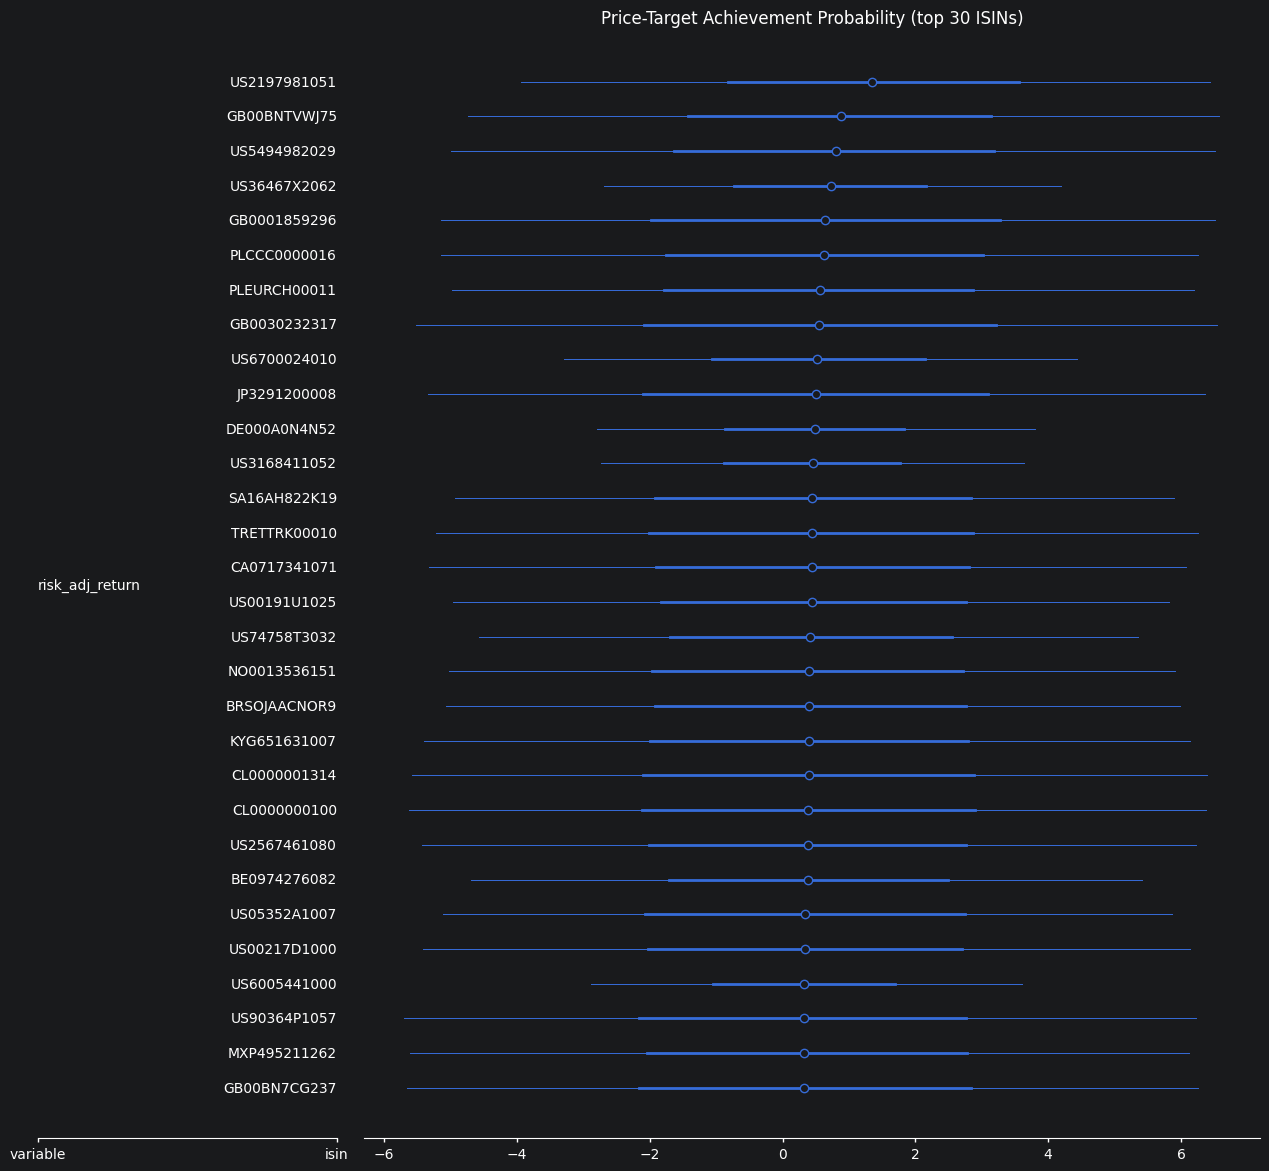

In [22]:
post = pt_idata.posterior
risk_adj = post["risk_adj_return"]
top_n = min(30, risk_adj.sizes.get("isin", 0))
risk_adj_mean = risk_adj.mean(("chain", "draw"))
# Use ["isin"] (not .isin) — `.isin` collides with xarray's DataArray.isin() method.
top_isins = risk_adj_mean.sortby(risk_adj_mean, ascending=False)["isin"].values[:top_n]
azp.plot_forest(
    pt_idata,
    var_names=["risk_adj_return"],
    coords={"isin": top_isins},
    combined=True,
)
plt.title(f"Price-Target Achievement Probability (top {top_n} ISINs)")
plt.tight_layout()
plt.show()

### 6.6 Out-of-sample prediction via `pm.set_data`

```python
with pt_pmodel:
    pm.set_data({
        "upside_potential":   new_upside,
        "analyst_conviction": new_conviction,
    })
    pt_ppc = pm.sample_posterior_predictive(pt_idata)
```


## 7. Kalman Filter Price Target — `KalmanFilterPriceTarget`

Per-ISIN GaussianRandomWalk state-space; `pm.Data` container `price_target`
along the `time` dim.

### 7.1 Prepare inputs (per-ISIN time series)

| Container       | Source column   | Dim    |
|-----------------|-----------------|--------|
| `price_target`  | `price_target`  | `time` |
| `time` coord    | a date column   | —      |
| `isin` coord    | selected ISIN   | —      |

The in-memory `df` is often a point-in-time snapshot with one row per ISIN, so
we probe several plausible date columns and gracefully skip if no ISIN has
≥ 2 observations.


In [23]:
_date_candidates = [
    "income_statement_report_date",
    "last_updated",
    "next_income_statement_report_date",
    "reference_date",
    "next_fy_end_date",
    "fy_end_date",
]
_date_col, _eligible = None, None
for _c in _date_candidates:
    if _c not in df.columns:
        continue
    _hist = df.dropna(subset=[_c, "price_target", id_col]).groupby(id_col).size()
    _cand = _hist[_hist >= 2]
    if not _cand.empty:
        _date_col, _eligible = _c, _cand
        break
print(f"Selected date column: {_date_col}")


Selected date column: None


### 7.2 Build the auxiliary feature alignment

Kalman uses no auxiliary feature matrix — the `time` coord is the only design
dim. The selected ISIN becomes the lone `isin` coord.


### 7.3 Fit the state-space model


In [24]:
if _eligible is None or _eligible.empty:
    import warnings
    warnings.warn(
        "No ISIN has >= 2 non-null price_target observations across known date "
        "columns. Skipping Kalman fit (point-in-time snapshot detected).",
        stacklevel=1,
    )
    kf_idata, kf_pmodel = None, None
else:
    _pt_isins = set(pt_df[id_col].astype(str).tolist())
    _candidates = _eligible[_eligible.index.astype(str).isin(_pt_isins)]
    target_isin = (_candidates if not _candidates.empty else _eligible).idxmax()
    ts = (
        df.loc[df[id_col] == target_isin, [_date_col, "price_target"]]
          .dropna()
          .sort_values(_date_col)
    )
    print(f"Selected ISIN={target_isin} ({len(ts)} obs, date col '{_date_col}')")

    kf_model = KalmanFilterPriceTarget()
    kf_idata, kf_pmodel = kf_model.fit(
        price_targets=ts["price_target"].to_numpy(),
        isin=target_isin,
        dates=pd.DatetimeIndex(ts[_date_col]),
        samples=1000, tune=1000, chains=4,
        target_accept=0.8, random_seed=42, nuts_sampler="nutpie",
        idata_kwargs={"log_likelihood": False},
    )


C:\Users\markm\AppData\Local\Temp\ipykernel_42892\3590350836.py:3: UserWarning: No ISIN has >= 2 non-null price_target observations across known date columns. Skipping Kalman fit (point-in-time snapshot detected).
  warnings.warn(


### 7.4 Inspect the `constant_data` group


In [25]:
if kf_idata is not None:
    print("constant_data:", list(kf_idata.constant_data.data_vars))
    print(kf_idata.constant_data)


### 7.5 Posterior diagnostics


In [26]:
if kf_idata is not None:
    display(azs.summary(kf_idata, var_names=["sigma_state", "sigma_obs"], round_to=3))
    azp.plot_trace(kf_idata, var_names=["sigma_state", "sigma_obs"]); plt.show()
    azp.plot_forest(kf_idata, var_names=["state"], combined=True); plt.show()


### 7.6 Out-of-sample prediction via `pm.set_data`

```python
with kf_pmodel:
    pm.set_data({"price_target": new_price_targets})
    kf_ppc = pm.sample_posterior_predictive(kf_idata)
```


## 8. DCF Price Target Regression — `DCFPriceTarget`

Bayesian DCF: priors on FCF growth and WACC, fits intrinsic value vs observed
price. Treats the per-ISIN FCF column as the historical FCF vector and the
per-ISIN price column as observed prices (matches `expected_returns_v4._run_dcf`).

### 8.1 Prepare inputs

| Container          | Source column | Dim    |
|--------------------|---------------|--------|
| `historical_fcf`   | `fcf_fy`      | `time` |
| `price_target`     | `last_price`  | `isin` |


In [27]:
dcf_cols = ["fcf_fy", "last_price"]
dcf_df = (
    df.dropna(subset=dcf_cols + [id_col])
      .drop_duplicates(subset=id_col)
      .reset_index(drop=True)
)
print(f"Prepared inputs: {len(dcf_df)} stocks")


Prepared inputs: 6653 stocks


### 8.2 Build the auxiliary `dcf_features` matrix

Aligned to `calculated_features_registry` (categories `Cash Flow` / `Valuation`).


In [28]:
spec = MODEL_FEATURE_CONTAINERS["DCF"]
dcf_available = [c for c in spec["features"] if c in dcf_df.columns]
dcf_features_df = (
    dcf_df[[id_col] + dcf_available].rename(columns={id_col: "isin"})
)
print(f"[DCF] {len(dcf_available)} catalogue-aligned features present in df.")


[DCF] 25 catalogue-aligned features present in df.


### 8.3 Fit the DCF Bayesian model


In [29]:
dcf_model = DCFPriceTarget()
dcf_idata, dcf_pmodel = dcf_model.fit(
    historical_fcf=dcf_df["fcf_fy"].to_numpy("float64"),
    price_target=dcf_df["last_price"].to_numpy("float64"),
    samples=1000, tune=1000, chains=4, nuts_sampler="nutpie",
    idata_kwargs={"log_likelihood": False},
)


C:\Users\markm\AppData\Local\Programs\Python\Python314\Lib\site-packages\pymc\sampling\mcmc.py:361: UserWarning: `idata_kwargs` are currently ignored by the nutpie sampler
  warnings.warn(


### 8.4 Inspect the `constant_data` group


In [30]:
print("constant_data:", list(dcf_idata.constant_data.data_vars))
print(dcf_idata.constant_data)


constant_data: ['price_target']
<xarray.Dataset> Size: 106kB
Dimensions:             (price_target_dim_0: 6653)
Coordinates:
  * price_target_dim_0  (price_target_dim_0) int64 53kB 0 1 2 ... 6650 6651 6652
Data variables:
    price_target        (price_target_dim_0) float64 53kB 3.7 1.77 ... 885.1
Attributes:
    created_at:                 2026-04-29T18:36:36.333463+00:00
    creation_library:           ArviZ
    creation_library_version:   1.0.0
    creation_library_language:  Python
    inference_library:          pymc
    inference_library_version:  5.28.4


### 8.5 Posterior diagnostics


C:\Users\markm\AppData\Local\Programs\Python\Python314\Lib\site-packages\arviz_stats\base\diagnostics.py:90: RuntimeWarning: divide by zero encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
fcf_growth,4.290416e+10,5.400000e-01,4.290416e+10,4.290416e+10,4.032,4.032,inf,2.690000e-01,1.250000e-01
wacc_interval__,1.049400e+01,7.850000e-01,9.686000e+00,1.139600e+01,4.142,4.032,6.212,3.910000e-01,4.400000e-02
sigma_log__,8.248100e+01,0.000000e+00,8.248100e+01,8.248100e+01,4.032,4.032,inf,0.000000e+00,0.000000e+00
wacc,3.000000e-01,0.000000e+00,3.000000e-01,3.000000e-01,4.141,4.032,18.664,0.000000e+00,0.000000e+00
sigma,6.621945e+35,1.613163e+31,6.621773e+35,6.622117e+35,4.032,4.032,inf,8.034492e+30,5.412613e+29
intrinsic_value,1.075208e+67,5.235489e+62,1.075152e+67,1.075264e+67,4.141,4.566,18.665,2.607578e+62,1.776847e+61


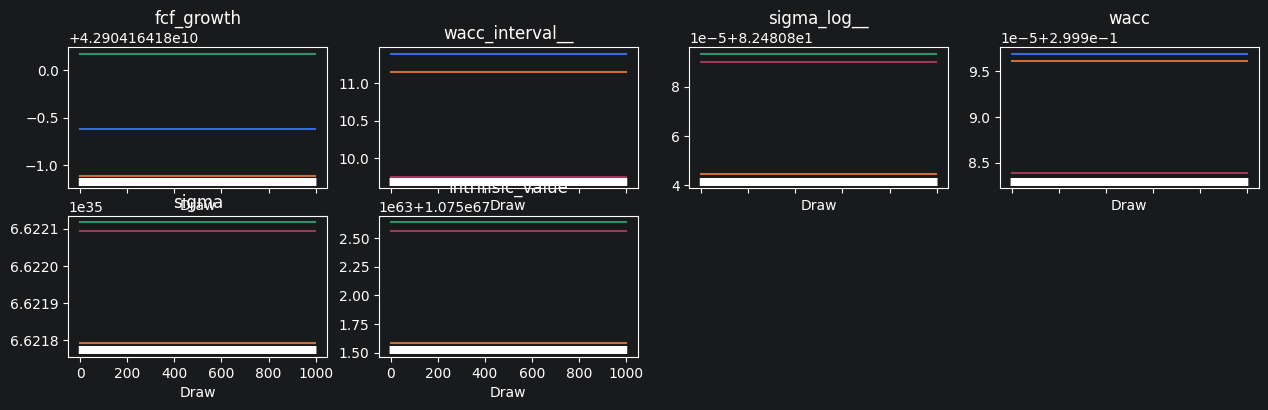

In [31]:
display(azs.summary(dcf_idata, round_to=3).head(20))
azp.plot_trace(dcf_idata); plt.show()


### 8.6 Out-of-sample prediction via `pm.set_data`

```python
with dcf_pmodel:
    pm.set_data({
        "historical_fcf": new_fcf,
        "price_target":   new_prices,
    })
    dcf_ppc = pm.sample_posterior_predictive(dcf_idata)
```


## 9. Dividend Safety Model — `DividendSafetyBayesian`

Maps to `build_dividend_safety_inference_data`.

### 9.1 Prepare inputs

| Container             | Source column            | Dim       |
|-----------------------|--------------------------|-----------|
| `payout_data`         | `dividend_payout_ratio`  | `ticker`  |
| `fcf_coverage_data`   | `fcf_dividend_coverage`  | `ticker`  |
| `ticker` coord        | `isin`                   | —         |


In [32]:
ds_mask = (
    df["dividend_payout_ratio"].notna()
    & df["fcf_dividend_coverage"].notna()
    & df[id_col].notna()
)
ds_df = df.loc[ds_mask].drop_duplicates(subset=id_col).reset_index(drop=True)
print(f"Prepared inputs: {len(ds_df)} stocks")


Prepared inputs: 2158 stocks


### 9.2 Build the auxiliary `dividend_features` matrix

Aligned to `calculated_features_registry` (categories `Dividends` / `Cash Flow`).


In [33]:
spec = MODEL_FEATURE_CONTAINERS["DividendSafety"]
div_available = [c for c in spec["features"] if c in ds_df.columns]
dividend_features_df = (
    ds_df[[id_col] + div_available].rename(columns={id_col: "isin"})
)
print(f"[DividendSafety] {len(div_available)} catalogue-aligned features present in df.")


[DividendSafety] 18 catalogue-aligned features present in df.


### 9.3 Fit the dividend safety model


In [34]:
ds_model = DividendSafetyBayesian(
    prior_alpha=2.0, prior_beta=5.0, high_payout_threshold=0.9
)
ds_idata, ds_pmodel = ds_model.fit(
    payout_ratios=ds_df["dividend_payout_ratio"].to_numpy("float64"),
    fcf_coverage=ds_df["fcf_dividend_coverage"].to_numpy("float64"),
    tickers=ds_df[id_col].astype(str).to_numpy(),
    samples=1000, tune=1000, chains=4, nuts_sampler="nutpie",
    idata_kwargs={"log_likelihood": False},
)


C:\Users\markm\AppData\Local\Programs\Python\Python314\Lib\site-packages\pymc\sampling\mcmc.py:361: UserWarning: `idata_kwargs` are currently ignored by the nutpie sampler
  warnings.warn(


Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.14,31
,2000,0,0.13,31
,2000,0,0.12,31
,2000,0,0.00,255


### 9.4 Inspect the `constant_data` group


In [35]:
print("constant_data:", list(ds_idata.constant_data.data_vars))
print(ds_idata.constant_data)


constant_data: ['payout_data']
<xarray.Dataset> Size: 121kB
Dimensions:      (ticker: 2158)
Coordinates:
  * ticker       (ticker) <U12 104kB 'AEA001901015' ... 'ZAE000006284'
Data variables:
    payout_data  (ticker) float64 17kB 0.9503 0.7168 0.9271 ... 1.437 -1.635
Attributes:
    created_at:                 2026-04-29T18:37:37.337193+00:00
    creation_library:           ArviZ
    creation_library_version:   1.0.0
    creation_library_language:  Python
    inference_library:          pymc
    inference_library_version:  5.28.4


### 9.5 Posterior diagnostics


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
cut_prob[AEA001901015],0.307,0.139,0.085,0.534,48.816,195.648,1.212,0.018,0.013
cut_prob[AEA003001012],0.351,0.177,0.077,0.583,12.080,24.798,1.234,0.055,0.025
cut_prob[AEA006101017],0.328,0.154,0.083,0.543,20.088,170.622,1.128,0.036,0.021
cut_prob[AEA007301012],0.296,0.138,0.081,0.540,474.898,148.692,1.274,0.002,0.002
cut_prob[AED000701014],0.319,0.154,0.072,0.544,26.047,143.389,1.094,0.032,0.020
cut_prob[AED001801011],0.296,0.135,0.087,0.530,233.588,165.970,1.291,0.002,0.002
cut_prob[AEE000401019],0.290,0.140,0.079,0.547,1584.153,132.693,1.350,0.002,0.002
cut_prob[AEE000601014],0.321,0.150,0.077,0.546,34.777,251.013,1.073,0.028,0.018
cut_prob[AEE000701012],0.335,0.166,0.079,0.566,14.679,27.461,1.181,0.046,0.023
cut_prob[AEE01072B225],0.327,0.152,0.085,0.525,19.221,311.572,1.135,0.038,0.022


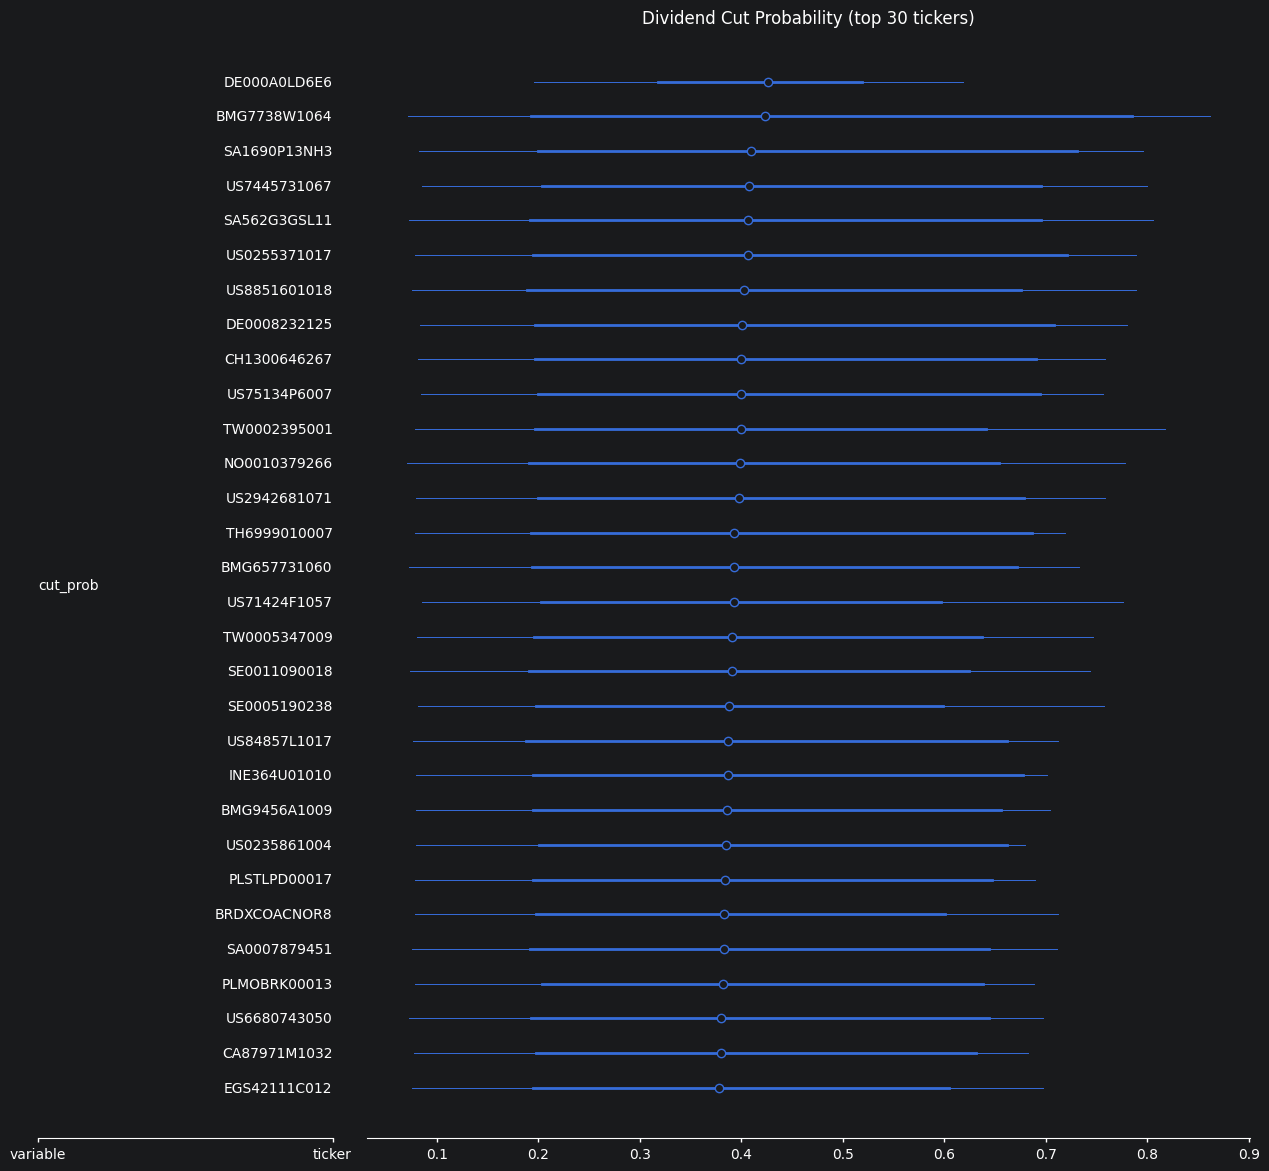

In [36]:
# Section 9.5 — Dividend Safety: top 30 ISINs by cut_prob
display(azs.summary(
    ds_idata,
    var_names=["cut_prob", "risk_adj", "expected_coverage"],
    round_to=3,
).head(10))

cut_prob = ds_idata.posterior["cut_prob"]
isin_dim = "isin" if "isin" in cut_prob.dims else ("ticker" if "ticker" in cut_prob.dims else None)
if isin_dim is not None:
    top_n = min(30, cut_prob.sizes[isin_dim])
    cut_mean = cut_prob.mean(("chain", "draw"))
    # Use [isin_dim] (not .isin) — `.isin` collides with xarray's DataArray.isin() method.
    top_isins = cut_mean.sortby(cut_mean, ascending=False)[isin_dim].values[:top_n]
    azp.plot_forest(
        ds_idata,
        var_names=["cut_prob"],
        coords={isin_dim: top_isins},
        combined=True,
    )
    plt.title(f"Dividend Cut Probability (top {top_n} {isin_dim}s)")
else:
    azp.plot_forest(ds_idata, var_names=["cut_prob"], combined=True)
    plt.title("Dividend Cut Probability")
plt.tight_layout()
plt.show()


### 9.6 Out-of-sample prediction via `pm.set_data`

```python
with ds_pmodel:
    pm.set_data({
        "payout_data":        new_payouts,
        "fcf_coverage_data":  new_coverage,
    })
    ds_ppc = pm.sample_posterior_predictive(ds_idata)
```


## 10. Credit Risk Bayesian Model — hierarchical by sector

Maps to `build_credit_risk_inference_data`.

### 10.1 Prepare inputs

| Container                  | Source column          | Dim      |
|----------------------------|------------------------|----------|
| `z_score_data`             | `altman_z_score`       | `ticker` |
| `de_data`                  | `debt_to_equity`       | `ticker` |
| `sector_idx`               | `sector` (factorized)  | `ticker` |
| `ticker` / `sector` coords | `isin`, `sector`       | —        |


In [37]:
cr_cols = ["altman_z_score", "debt_to_equity", id_col, "sector"]
cr_df = (
    df.dropna(subset=cr_cols)
      .drop_duplicates(subset=id_col)
      .reset_index(drop=True)
)
print(f"Prepared inputs: {len(cr_df)} stocks across {cr_df['sector'].nunique()} sectors")


Prepared inputs: 5538 stocks across 9 sectors


### 10.2 Build the auxiliary `credit_risk_features` matrix

Aligned to `calculated_features_registry` (categories `Credit Risk` /
`Quality & Risk`).


In [38]:
spec = MODEL_FEATURE_CONTAINERS["CreditRisk"]
cr_available = [c for c in spec["features"] if c in cr_df.columns]
credit_features_df = (
    cr_df[[id_col] + cr_available].rename(columns={id_col: "isin"})
)
print(f"[CreditRisk] {len(cr_available)} catalogue-aligned features present in df.")


[CreditRisk] 35 catalogue-aligned features present in df.


### 10.3 Fit the hierarchical credit risk model


In [39]:
cr_model = CreditRiskBayesian(prior_alpha=2.0, prior_beta=3.0)
cr_idata, cr_pmodel = cr_model.fit(
    z_scores=cr_df["altman_z_score"].to_numpy("float64"),
    debt_to_equity=cr_df["debt_to_equity"].to_numpy("float64"),
    tickers=cr_df[id_col].astype(str).to_numpy(),
    sectors=cr_df["sector"].astype(str).to_numpy(),
    samples=1000, tune=1000, chains=4,
    parameterization="non_centered", nuts_sampler="nutpie",
    idata_kwargs={"log_likelihood": False},
)


C:\Users\markm\AppData\Local\Programs\Python\Python314\Lib\site-packages\pymc\sampling\mcmc.py:361: UserWarning: `idata_kwargs` are currently ignored by the nutpie sampler
  warnings.warn(
C:\Users\markm\AppData\Local\Programs\Python\Python314\Lib\site-packages\pytensor\tensor\rewriting\elemwise.py:881: UserWarning: Loop fusion failed because the resulting node would exceed the kernel argument limit.
  warn(


Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,742,0.10,25
,2000,904,0.10,5
,2000,841,0.09,55
,2000,800,0.09,10


### 10.4 Inspect the `constant_data` group


In [40]:
print("constant_data:", list(cr_idata.constant_data.data_vars))
print("coords:        ", list(cr_idata.constant_data.coords))
print(cr_idata.constant_data)


constant_data: ['z_score_data', 'de_data', 'sector_idx']
coords:         ['ticker']
<xarray.Dataset> Size: 377kB
Dimensions:       (ticker: 5538)
Coordinates:
  * ticker        (ticker) <U12 266kB 'AEA001901015' ... 'ZAE000351946'
Data variables:
    z_score_data  (ticker) float64 44kB 1.95 2.51 2.11 1.01 ... 9.5 5.37 2.23
    de_data       (ticker) float64 44kB 0.7113 0.7602 0.3307 ... 2.305 0.3264
    sector_idx    (ticker) int32 22kB 2 5 5 5 1 3 5 3 0 1 ... 1 3 7 5 2 7 1 2 1
Attributes:
    created_at:                 2026-04-29T18:41:22.283103+00:00
    creation_library:           ArviZ
    creation_library_version:   1.0.0
    creation_library_language:  Python
    inference_library:          pymc
    inference_library_version:  5.28.4


### 10.5 Posterior diagnostics


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
sector_rate[Communication Services],0.998,0.000,0.998,0.999,17.555,16.206,1.174,0.0,0.0
sector_rate[Consumer Discretionary],0.998,0.000,0.998,0.999,46.335,61.752,1.080,0.0,0.0
sector_rate[Consumer Staples],0.998,0.000,0.998,0.999,42.447,89.830,1.084,0.0,0.0
sector_rate[Energy],0.998,0.000,0.998,0.999,40.049,74.553,1.082,0.0,0.0
sector_rate[Health Care],0.999,0.000,0.998,0.999,72.392,111.758,1.019,0.0,0.0
sector_rate[Industrials],0.999,0.000,0.998,0.999,46.864,42.012,1.064,0.0,0.0
sector_rate[Information Technology],0.998,0.000,0.998,0.999,19.472,31.981,1.144,0.0,0.0
sector_rate[Materials],0.999,0.000,0.998,0.999,17.365,26.965,1.171,0.0,0.0
sector_rate[Utilities],0.998,0.000,0.998,0.999,73.149,120.431,1.053,0.0,0.0
distress_prob[AEA001901015],0.998,0.003,0.993,1.000,249.923,241.608,1.011,0.0,0.0


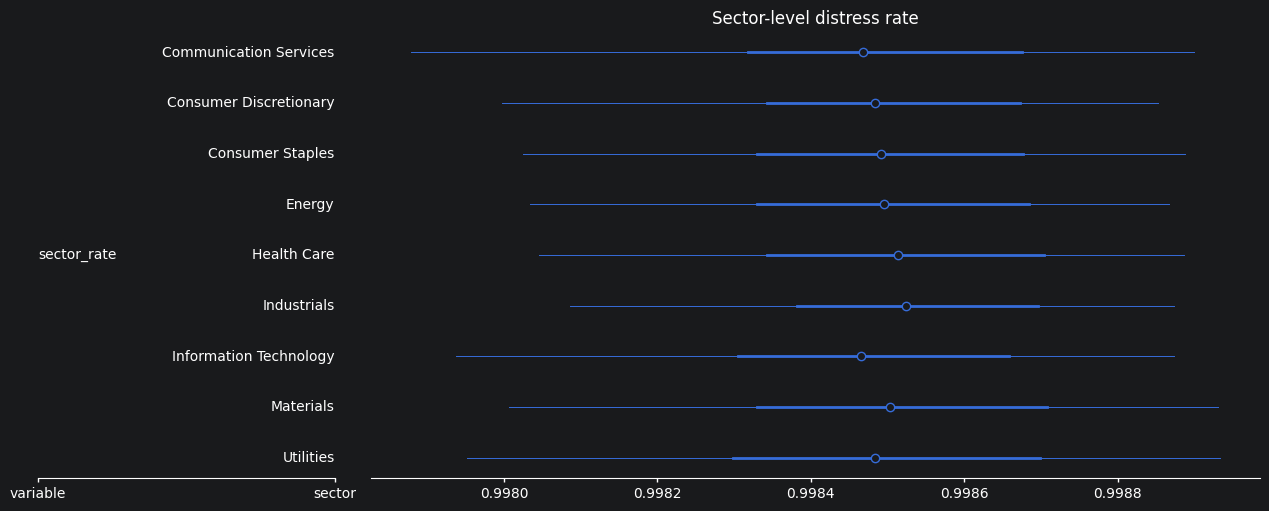

In [41]:
display(azs.summary(
    cr_idata, var_names=["sector_rate", "distress_prob"], round_to=3
).head(20))
azp.plot_forest(cr_idata, var_names=["sector_rate"], combined=True)
plt.title("Sector-level distress rate")
plt.tight_layout()
plt.show()


### 10.6 Out-of-sample prediction via `pm.set_data`

```python
with cr_pmodel:
    pm.set_data({
        "z_score_data": new_z,
        "de_data":      new_de,
        "sector_idx":   new_sector_idx,
    })
    cr_ppc = pm.sample_posterior_predictive(cr_idata)
```


## 11. Accounting Anomaly Model — `AccountingAnomalyBayesian`

Maps to `build_accounting_anomaly_inference_data`.
The feature matrix is keyed by `calculated_features_registry`
(categories `Accounting Quality` / `Quality & Risk` / `Anomaly`).

### 11.1 Prepare inputs

| Container        | Source                              | Dims              |
|------------------|-------------------------------------|-------------------|
| `feature_values` | `aa_df[aa_features]` matrix         | `(isin, feature)` |
| `isin` coord     | `isin`                              | —                 |
| `feature` coord  | `calculated_features_registry`      | —                 |


In [42]:
spec = MODEL_FEATURE_CONTAINERS["AccountingAnomaly"]
aa_features = [c for c in spec["features"] if c in df.columns]
aa_df = (
    df.dropna(subset=aa_features + [id_col])
      .drop_duplicates(subset=id_col)
      .reset_index(drop=True)
)
print(f"[AccountingAnomaly] {len(aa_df)} stocks x {len(aa_features)} catalogue-aligned features")


[AccountingAnomaly] 3001 stocks x 35 catalogue-aligned features


### 11.2 Build the auxiliary `feature_values` matrix

Labels for the `feature` dim are pulled directly from
`public.calculated_features_registry` so the model coords stay DB-aligned.


In [43]:
accounting_features_df = (
    aa_df[[id_col] + aa_features]
    .rename(columns={id_col: "isin"})
    .drop_duplicates("isin")
)
print(accounting_features_df.shape)


(3001, 36)


### 11.3 Fit the multi-layer anomaly model


In [44]:
aa_model = AccountingAnomalyBayesian(threshold=2.0)
aa_idata, aa_pmodel = aa_model.fit(
    feature_values=aa_df[aa_features].to_numpy("float64"),
    isins=aa_df[id_col].astype(str).to_numpy(),
    feature_names=aa_features,
    samples=1000, tune=1000, chains=4, nuts_sampler="nutpie",
    idata_kwargs={"log_likelihood": False},
)


C:\Users\markm\AppData\Local\Programs\Python\Python314\Lib\site-packages\pymc\sampling\mcmc.py:361: UserWarning: `idata_kwargs` are currently ignored by the nutpie sampler
  warnings.warn(


Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,47,0.00,18
,2000,0,0.00,7
,2000,55,0.00,1
,2000,25,0.00,1


### 11.4 Inspect the `constant_data` group


In [45]:
print("constant_data:", list(aa_idata.constant_data.data_vars))
print("coords:        ", list(aa_idata.constant_data.coords))
print(aa_idata.constant_data)


constant_data: ['feature_values']
coords:         ['isin', 'feature']
<xarray.Dataset> Size: 988kB
Dimensions:         (isin: 3001, feature: 35)
Coordinates:
  * isin            (isin) <U12 144kB 'AEA001901015' ... 'ZAE000351946'
  * feature         (feature) <U27 4kB 'tax_rate_qoq_change' ... 'beta_stabil...
Data variables:
    feature_values  (isin, feature) float64 840kB 0.005104 0.01936 ... 0.3112
Attributes:
    created_at:                 2026-04-29T18:41:48.410139+00:00
    creation_library:           ArviZ
    creation_library_version:   1.0.0
    creation_library_language:  Python
    inference_library:          pymc
    inference_library_version:  5.28.4


### 11.5 Posterior diagnostics


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
anomaly_prob[AEA001901015],0.239,0.083,0.168,0.412,4.823,4.587,2.557,0.041,0.023
anomaly_prob[AEA002301017],0.171,0.066,0.115,0.311,4.823,4.587,2.557,0.033,0.019
anomaly_prob[AEA003001012],0.031,0.015,0.019,0.065,4.823,4.587,2.557,0.007,0.005
anomaly_prob[AEA004601018],0.303,0.095,0.220,0.495,4.823,4.587,2.557,0.047,0.026
anomaly_prob[AEA007601015],0.136,0.056,0.090,0.256,4.823,4.587,2.557,0.028,0.017
anomaly_prob[AEE000701012],0.080,0.035,0.051,0.158,4.823,4.587,2.557,0.018,0.011
anomaly_prob[AEE01268A239],0.104,0.044,0.067,0.201,4.823,4.587,2.557,0.022,0.013
anomaly_prob[AEF000901015],0.092,0.040,0.059,0.179,4.823,4.587,2.557,0.020,0.012
anomaly_prob[AEN000401010],0.143,0.058,0.094,0.266,4.823,4.587,2.557,0.029,0.017
anomaly_prob[AT000000ETS9],0.024,0.012,0.015,0.050,4.823,4.587,2.557,0.006,0.004


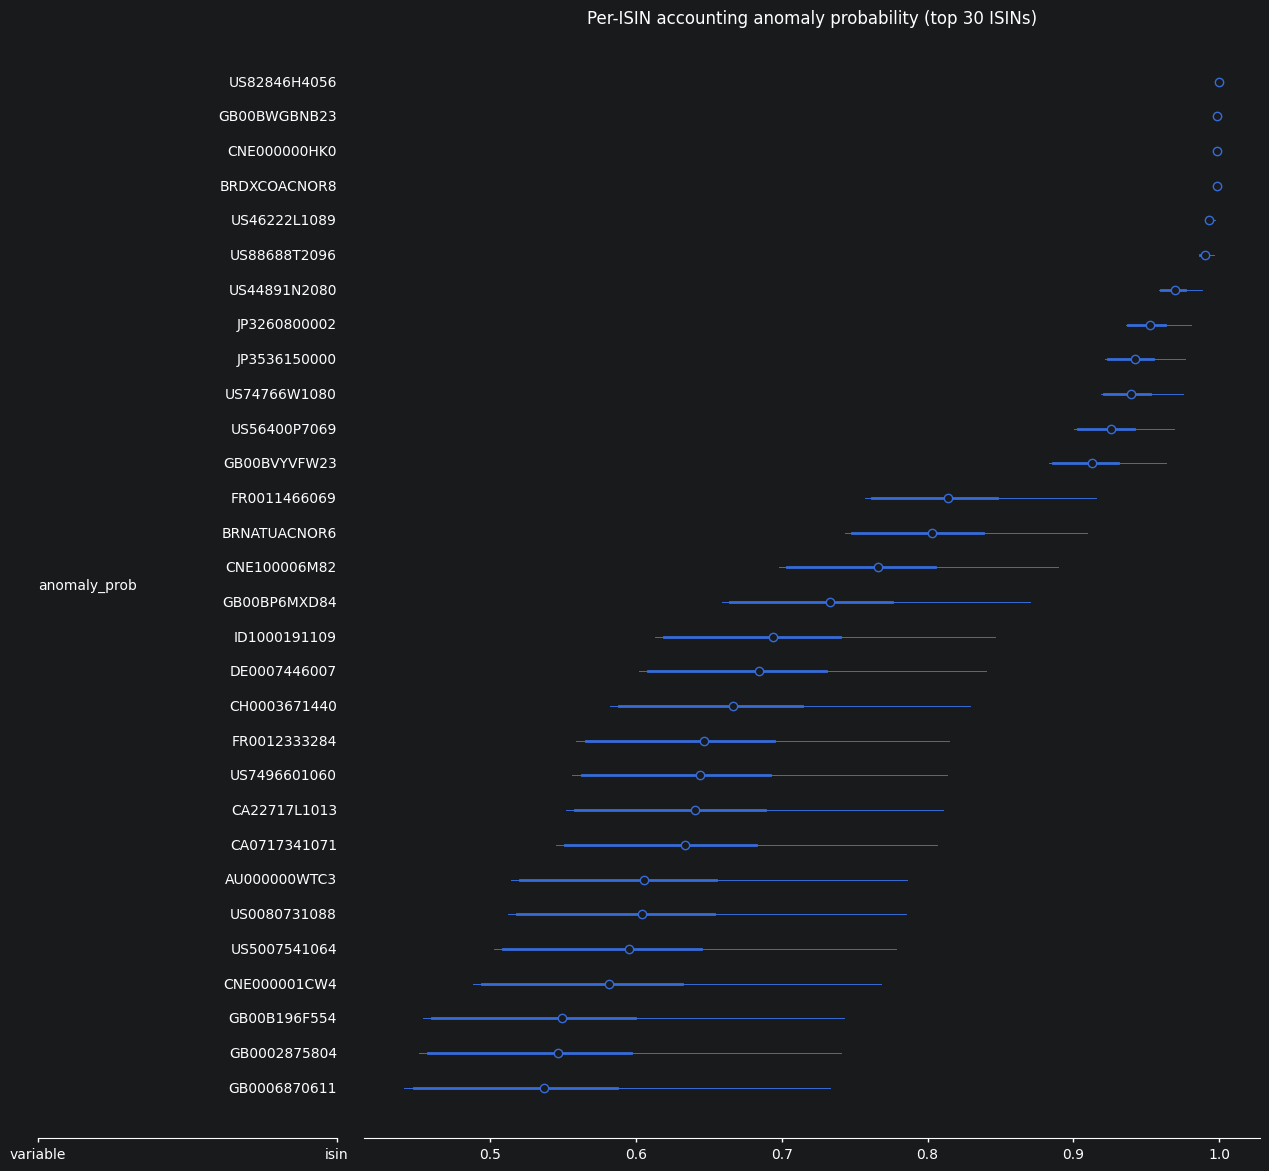

In [46]:
# Section 11.5 — Accounting Anomaly: top 30 ISINs by anomaly_prob
display(azs.summary(aa_idata, var_names=["anomaly_prob"], round_to=3).head(10))

anomaly_prob = aa_idata.posterior["anomaly_prob"]
top_n = min(30, anomaly_prob.sizes.get("isin", 0))
anomaly_mean = anomaly_prob.mean(("chain", "draw"))
# Use ["isin"] (not .isin) — `.isin` collides with xarray's DataArray.isin() method.
top_isins = anomaly_mean.sortby(anomaly_mean, ascending=False)["isin"].values[:top_n]
azp.plot_forest(
    aa_idata,
    var_names=["anomaly_prob"],
    coords={"isin": top_isins},
    combined=True,
)
plt.title(f"Per-ISIN accounting anomaly probability (top {top_n} ISINs)")
plt.tight_layout()
plt.show()


### 11.6 Out-of-sample prediction via `pm.set_data`

```python
with aa_pmodel:
    pm.set_data({"feature_values": new_feature_matrix})
    aa_ppc = pm.sample_posterior_predictive(aa_idata)
```
